# Task assignment


Consider an assignment problem where the goal is to assign n workers to n tasks such that the total cost is minimized. The problem can be formulated as:

$$ \min_x \sum_{i=1}^{n} \sum_{j=1}^{n} c_{ij} x_{ij} $$ $$ \sum_{j=1}^{n} x_{ij} = 1, \qquad \forall i \in \{ 1, \dots , n \} \\ \sum_{i=1}^{n} x_{ij} = 1, \qquad \forall j \in \{ 1, \dots , n \} \\ x_{ij} \in \{ 0, 1 \}, \qquad \forall i,j \in \{ 1, \dots , n \} $$

where $c_{ij}$ is the cost of assigning worker $i$ to task $j$.
Furthermore, $x_{ij} = 1$ if worker $i$ is assigned to task $j$, and $0$ otherwise.

# Distributionally robust optimization

#### 1. Formulate a Wasserstein distributionally robust optimization (DRO) problem with l1 or l∞ norm for the risk-averse objective function.

**Distributional Assumptions**

We assume that the $c_{ij}$ are independent random variables and satisfy:

$$
c_{ij} \sim \mathcal{N}(\mu_{ij}, \sigma_{ij}^2) = \mathbb{P}_{ij}, \quad \forall i,j.
$$

The parameters are defined as:
$$
\mu_{ij} = (n+1)i + j, \qquad
\sigma_{ij} = 1 + (n+1)i + j.
$$

**Formulation of Wasserstein distributionally robust optimization**

We flatten matrix $C_{n \times n}$ and $X_{n \times n}$ into vectors in then following way:
$$
\sum_{i=1}^{n} \sum_{j=1}^{n} c_{ij} x_{ij} = \mathbf{c}^{\top} \mathbf{x}
\\
\mathbf{c} = [c_1, c_2, \ldots, c_n]^\top \in \mathbb{R}^{n^2}
\\
\mathbf{x} = [x_1, x_2, \ldots, x_n]^\top \in \{0, 1\}^{n^2}
$$

Then, we can use general formulation of Risk-Averse Distributionally Robust Optimization(DRO):
$$
\min_{\mathbf{x} \in X, t \in \mathbb{R}} \max_{\mathbb{P} \in \mathcal{P}} \left\{ t + \frac{1}{1 - \alpha} \mathbb{E}_{\mathbb{P}} \left\{ \max \{\mathbf{c}^{\top} \mathbf{x} - t, 0 \} \right\} \right\}
$$

where

$$
U = \{\mathbf{c} \in \mathbb{R}^{n^2} : \mathbf{D}\mathbf{c} \leq \mathbf{g}\}
\\
\hat{C}_{train} = \{\hat{\mathbf{c}}^{(k)},\ k \in \{1, \dots, K\}\} \\
\mathcal{P} := \left\{\mathbb{P} : \mathbb{P}\{\mathbf{c} \in U\} = 1 \ \text{and} \ d_W(\hat{\mathbb{P}}_0, \mathbb{P}) \leq \varepsilon \right\}
\\
\hat{\mathbb{P}}_0(\hat{C}_{train}) := \frac{1}{K} \sum_{k=1}^K \delta_{\hat{\mathbf{c}}^{(k)}}
$$

It can be simplified to:
$$
\begin{align}
\min_{\mathbf{x}, \boldsymbol{\nu}, \mathbf{s}, \lambda, t} & \left\{ t + \frac{1}{1 - \alpha} \left( \lambda \varepsilon + \frac{1}{K} \sum_{k=1}^K s_k \right) \right\}
\\
\text{s.t.} \quad & \mathbf{x} \in \{0, 1\}^{n^2}
\\
& \lambda \ge 0
\\
& \hat{\mathbf{c}}^{(k)\top} \mathbf{x} - t + \boldsymbol{\Delta}^{(k)\top} \boldsymbol{\nu}^{(k)} \le s_k, \quad \forall k \in \{1, \dots, K\}, \nonumber
\\
& \| \mathbf{D}^\top \boldsymbol{\nu}^{(k)} - \mathbf{x} \|_{∞} \le \lambda, \quad \forall k \in \{1, \dots, K\}, \Longleftrightarrow -\lambda \leq \left( \mathbf{D}^\top \boldsymbol{\nu}^{(k)} - \mathbf{x} \right)_i \leq \lambda, \quad \forall i = \overline{1, n^2} \quad \forall k \in \{1, \dots, K\}, \nonumber
\\
& \boldsymbol{\nu}^{(k)} \ge 0, \ s_k \ge 0, \quad \forall k \in \{1, \dots, K\}
\end{align}
$$
where $\boldsymbol{\Delta}^{(k)} = \mathbf{g} - \mathbf{D}\hat{\mathbf{c}}^{(k)} \ge 0$ for each $k \in \{1, \dots, K\}$


In [1]:
!pip install gurobipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 20.7 MB/s eta 0:00:00


In [2]:
import json
import gurobipy as gp

GUROBI_CONF_PATH = "./gurobi_conf.json"


def set_environ(environ: gp.Env, conf_path: str = GUROBI_CONF_PATH):
    with open(conf_path, "r") as cfp:
        configuration = json.load(cfp)

    access_id = configuration["environ"].get("WLSAccessID")
    secret = configuration["environ"].get("WLSSecret")
    licence_id = configuration["environ"].get("LicenseID")

    print(f"NOTE: Got environment configuration parameters:\nWLSAccessID: {access_id},\nWLSSecret: {secret},\nLicenseID: {licence_id}\n")
    if all([access_id, secret, licence_id]):
        print(f"NOTE: found existing Gurobi licence")
        environ.setParam('WLSAccessID', access_id)
        environ.setParam('WLSSecret', secret)
        environ.setParam('LicenseID', licence_id)
    else:
        print(f"WARNING: some of the environment configuration parameters are None - using free Gurobi licence: you will not be able to solve large problems!")


def set_model_params(model: gp.Model, conf_path: str = GUROBI_CONF_PATH):
    with open(conf_path, "r") as cfp:
        configuration = json.load(cfp)

    output_flag = configuration["model"].get("OutputFlag", 0)
    log_to_console = configuration["model"].get("LogToConsole", 0)

    model.setParam("OutputFlag", output_flag)
    model.setParam("LogToConsole", log_to_console)

In [3]:
import numpy as np
from gurobipy import GRB


def build_box_uncertainty(samples):
    # bounds chosen by samples min/max
    l = samples.min(axis=0)
    u = samples.max(axis=0)
    dim = len(l)
    D = np.vstack([np.eye(dim), -np.eye(dim)])
    g = np.hstack([u, -l])
    return D, g


def assignment_constraints(model, x, n):
    def idx(i, j):
        return i * n + j

    for i in range(n):
        model.addConstr(sum(x[idx(i, j)] for j in range(n)) == 1)

    for j in range(n):
        model.addConstr(sum(x[idx(i, j)] for i in range(n)) == 1)


class DROAssignment:
    def __init__(self, n, epsilon, alpha, D, g, env):
        self.n = n
        self.epsilon = epsilon
        self.alpha = alpha
        self.D = D
        self.g = g
        self.env = env

    def solve(self, samples):
        K, dim = samples.shape
        n = self.n

        model = gp.Model("DRO_Assignment", env=self.env)
        set_model_params(model)

        # variables
        x = model.addVars(dim, vtype=GRB.BINARY, name="x")
        t = model.addVar(lb=-GRB.INFINITY, name="t")
        lam = model.addVar(lb=0, name="lambda")
        s = model.addVars(K, lb=0, name="s")

        nu = {}
        for k in range(K):
            nu[k] = model.addVars(self.D.shape[0], lb=0, name=f"nu_{k}")

        # assignment constraints
        assignment_constraints(model, x, n)

        # DRO constraints
        for k in range(K):
            c_k = samples[k]

            # Delta_k = g - D c_k
            Delta_k = self.g - self.D @ c_k

            # main constraint
            model.addConstr(
                gp.quicksum(c_k[i] * x[i] for i in range(dim))
                - t
                + gp.quicksum(Delta_k[j] * nu[k][j] for j in range(len(Delta_k)))
                <= s[k]
            )

            # infinity norm constraints
            for i in range(dim):
                expr = (
                    gp.quicksum(self.D[j, i] * nu[k][j] for j in range(self.D.shape[0]))
                    - x[i]
                )
                model.addConstr(expr <= lam)
                model.addConstr(expr >= -lam)

        # objective
        model.setObjective(
            t + (1 / (1 - self.alpha)) * (lam * self.epsilon + (1 / K) * gp.quicksum(s[k] for k in range(K))),
            GRB.MINIMIZE
        )

        model.optimize()

        x_sol = np.array([x[i].X for i in range(dim)])
        return x_sol.reshape((n, n)), model.objVal

#### 2. For each n ∈ {5, 10, . . . , 50}, generate 100 test instances of the problem by using k = 30 samples from the true distribution.

In [4]:
class DRODataGenerator:
    def __init__(self, seed=42):
        """
        Initialize random number generator for reproducibility.
        """
        self.rng = np.random.default_rng(seed)

    def generate_samples(self, n, K):
        """
        Generate K samples from the true distribution P*.

        Each sample corresponds to a cost matrix C (n x n),
        which is flattened into a vector of length n^2.

        Distribution:
            c_ij ~ N(mu_ij, sigma_ij^2)

        where:
            mu_ij = (n+1)*i + j
            sigma_ij = 1 + (n+1)*i + j

        Parameters:
            n (int): number of workers/tasks
            K (int): number of samples

        Returns:
            samples (np.ndarray): shape (K, n^2)
        """
        M = n + 1
        samples = []

        for _ in range(K):
            C = np.zeros((n, n))

            for i in range(n):
                for j in range(n):
                    # Note: using (i+1), (j+1) for 1-based indexing
                    mu = M * (i + 1) + (j + 1)
                    sigma = 1 + M * (i + 1) + (j + 1)

                    # Draw from normal distribution
                    C[i, j] = self.rng.normal(mu, sigma)

            # Flatten matrix into vector
            samples.append(C.flatten())

        return np.array(samples)  # shape: (K, n^2)

    def generate_experiment(self, n_values, num_instances=100, K=30):
        """
        Generate full experimental dataset.

        For each n in n_values:
            - create num_instances independent problem instances
            - each instance consists of K samples

        Parameters:
            n_values (list): list of problem sizes (e.g., [5, 10, ..., 50])
            num_instances (int): number of instances per n
            K (int): number of samples per instance

        Returns:
            data (dict):
                data[n] = list of instances
                each instance has shape (K, n^2)
        """
        data = {}

        for n in n_values:
            instances = []

            for _ in range(num_instances):
                samples = self.generate_samples(n, K)
                instances.append(samples)

            data[n] = instances

        return data

In [5]:
# simple usage example
env = gp.Env(empty=True)  # Initialize an empty environment
# Set license parameters using the environment
set_environ(env)
# Now, initialize the environment
env.start()

generator = DRODataGenerator(seed=1)
n_values = range(5, 51, 5)
results = {}
for n in n_values:
    results[n] = []
    for instance_id in range(100):
        # 1. generate data
        samples = generator.generate_samples(n, K=30)

        # 2. build uncertainty set
        D, g = build_box_uncertainty(samples)

        # 3. solve DRO
        solver = DROAssignment(
            n=n,
            epsilon=0.1,
            alpha=0.95,
            D=D,
            g=g,
            env=env
        )

        x_opt, obj = solver.solve(samples)

        results[n].append({
            "x": x_opt,
            "obj": obj
        })
        print(f"{x_opt=}, {obj=}")
env.close()

FileNotFoundError: [Errno 2] No such file or directory: './gurobi_conf.json'

#### 6. For fixed n, compute the average solution times as a function of ε.

NOTE: Got environment configuration parameters:
WLSAccessID: c883e76c-6b5d-4a16-9dc8-dd44f341af22,
WLSSecret: 1721a792-2ef0-4ae2-a7c7-993621b5fcca,
LicenseID: 2799306

NOTE: found existing Gurobi licence
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2799306
Academic license 2799306 - for non-commercial use only - registered to se___@business.uzh.ch
Solving for epsilon = 0.0000
  processed 10/10 instances
Solving for epsilon = 0.5000
  processed 10/10 instances
Solving for epsilon = 1.0000
  processed 10/10 instances
Solving for epsilon = 1.5000
  processed 10/10 instances
Solving for epsilon = 2.0000
  processed 10/10 instances


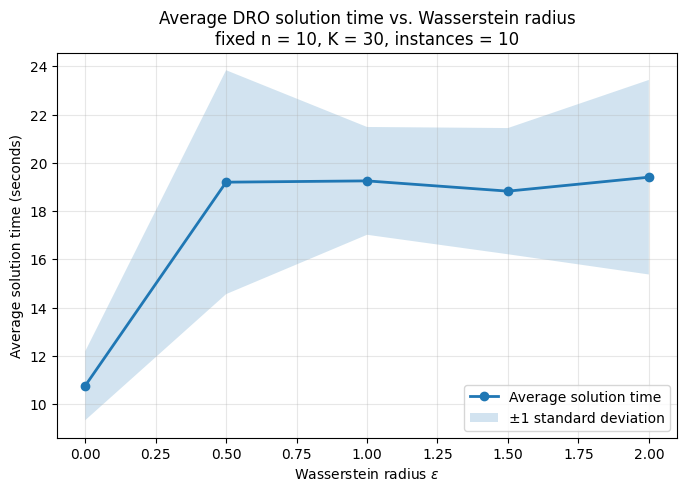

Mean solution times: [10.76186881 19.20231606 19.25597791 18.83008645 19.4081809 ]
Std. deviations: [1.42844707 4.64116546 2.2346541  2.61595461 4.03227576]


In [8]:
import time
import matplotlib.pyplot as plt


def average_solution_time_vs_epsilon(
    n_fixed=10,
    epsilon_grid=None,
    num_instances=100,
    K=30,
    alpha=0.95,
    seed=123,
    show_progress=True,
):
    """
    Compute the average DRO solution time as a function of the Wasserstein radius ε
    for a fixed problem size n.

    The same randomly generated instances are reused for all ε values so that the
    comparison is fair. Sample generation and uncertainty-set construction are done
    once in advance and are NOT included in the measured time.
    """
    if epsilon_grid is None:
        epsilon_grid = np.linspace(0.0, 2.0, 9)

    epsilon_grid = np.asarray(epsilon_grid, dtype=float)
    generator = DRODataGenerator(seed=seed)

    # Pre-generate all instances
    instances = []
    for _ in range(num_instances):
        samples = generator.generate_samples(n_fixed, K=K)
        D, g = build_box_uncertainty(samples)
        instances.append((samples, D, g))

    mean_times = []
    std_times = []
    raw_times = {float(eps): [] for eps in epsilon_grid}

    # Reuse one Gurobi environment
    env = gp.Env(empty=True)
    set_environ(env)
    env.start()

    try:
        for eps in epsilon_grid:
            if show_progress:
                print(f"Solving for epsilon = {eps:.4f}")

            current_times = []

            for instance_id, (samples, D, g) in enumerate(instances, start=1):
                solver = DROAssignment(
                    n=n_fixed,
                    epsilon=float(eps),
                    alpha=alpha,
                    D=D,
                    g=g,
                    env=env
                )

                start_time = time.perf_counter()
                _x_opt, _obj = solver.solve(samples)
                elapsed = time.perf_counter() - start_time

                current_times.append(elapsed)

                if show_progress and instance_id % 10 == 0:
                    print(f"  processed {instance_id}/{num_instances} instances")

            raw_times[float(eps)] = current_times
            mean_times.append(np.mean(current_times))
            std_times.append(np.std(current_times, ddof=1) if len(current_times) > 1 else 0.0)

    finally:
        env.close()

    mean_times = np.asarray(mean_times)
    std_times = np.asarray(std_times)

    plt.figure(figsize=(8, 5))
    plt.plot(epsilon_grid, mean_times, marker='o', linewidth=2, label='Average solution time')
    plt.fill_between(
        epsilon_grid,
        mean_times - std_times,
        mean_times + std_times,
        alpha=0.2,
        label='±1 standard deviation'
    )
    plt.xlabel(r'Wasserstein radius $\varepsilon$')
    plt.ylabel('Average solution time (seconds)')
    plt.title(
        f'Average DRO solution time vs. Wasserstein radius\n'
        f'fixed n = {n_fixed}, K = {K}, instances = {num_instances}'
    )
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    return {
        "epsilon_grid": epsilon_grid,
        "mean_times": mean_times,
        "std_times": std_times,
        "raw_times": raw_times,
    }


# Example run
timing_vs_epsilon_results = average_solution_time_vs_epsilon(
    n_fixed=10,
    epsilon_grid=np.linspace(0.0, 2.0, 5),
    num_instances=10,
    K=30,
    alpha=0.95,
    seed=123,
    show_progress=True,
)

print("Mean solution times:", timing_vs_epsilon_results["mean_times"])
print("Std. deviations:", timing_vs_epsilon_results["std_times"])